In [1]:
%pip install -r requirements.txt

  Using cached plotly-6.5.1-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.5.1-py3-none-any.whl (9.9 MB)
  Attempting uninstall: plotly
    Found existing installation: plotly 6.3.1
    Not uninstalling plotly at /layers/paketo-buildpacks_poetry-install/poetry-venv/datascience-python-renku-dependencies-xS3fZVNL-py3.13/lib/python3.13/site-packages, outside environment /home/renku/work/.venv
    Can't uninstall 'plotly'. No files were found to uninstall.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install --no-deps notify-run

Note: you may need to restart the kernel to use updated packages.


In [3]:
from notify_run import Notify
notify = Notify()
# notify.register()  # run once, subscribe and then reuse that

In [4]:
notify = Notify(endpoint="https://notify.run/62tjrWLW3vqBmEwI3pn2")

In [5]:
import os
from dirsync import sync
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from params import Params, save_params_json
from datasets import (
    Era5Metadata,
    load_era5_data,
    load_high_res_topography,
    prepare_meteoswiss_targets,
    calculate_dists_meteoswiss,
    save_metadata_json,
)
from convCNP.models.elev_models import TmaxBiasConvCNPElev, GammaBiasConvCNPElev
from convCNP.models.cnn import CNN, ResConvBlock
from convCNP.training.training_elev import train_elev
from convCNP.training.loss_functions import gll, gamma_ll
from convCNP.training.utils import get_value_tmax

In [6]:
if "RENKU_PROJECT_ID" in os.environ:
    device = torch.device('cpu')
elif torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: cpu


In [7]:
# Training configuration - modify these parameters as needed
PARAMS = Params(
    VARIABLE='tmax',
    DATA_YEAR_START=2023,  # Set to None for full dataset
    N_EPOCHS=100,
    N_FOLDS=5,
    TRIAL_NAME='base-100-5folds-with-patience',
    RUN_TYPE='cloud' if "RENKU_PROJECT_ID" in os.environ else 'local',
    BATCH_SIZE=16,
    DEVICE=device.type,
    IN_CHANNELS = 0,  # This will be replaced after dynamic computation below
)

print(f"Configuration: {PARAMS}")

Configuration: Params(VARIABLE='tmax', DATA_YEAR_START=2023, N_CHANNELS=128, N_BLOCKS=6, KERNEL_SIZE=5, LENGTH_SCALE=0.1, IN_CHANNELS=0, N_EPOCHS=100, BATCH_SIZE=16, LR=0.0005, PATIENCE=10, N_FOLDS=5, SEED=42, TRIAL_NAME='base-100-5folds-with-patience', RUN_TYPE='cloud', DEVICE='cpu')


In [8]:
def sync_from_cloud_if_needed(remote_path: Path, local_path: Path, run_type: str):
    # If running in cloud, sync data from network mount to local storage first
    if run_type == 'cloud':
        print(f"Cloud run detected. Syncing data from {remote_path} to {local_path}...")

        # Create local directories
        local_path.mkdir(parents=True, exist_ok=True)

        # Sync datasets from network mount to local storage
        # Using dirsync: only_newer=True skips existing complete files
        sync(str(remote_path), str(local_path), 'sync', only_newer=True, verbose=True)
        print(f"Dataset sync complete.")

def sync_to_cloud_if_needed(local_path: Path, remote_path: Path, run_type: str):
    # If running in cloud, sync trained models from local storage to network mount
    if run_type == 'cloud':
        print(f"Cloud run detected. Syncing trained models from {local_path} to {remote_path}...")

        # Create remote directories
        remote_path.mkdir(parents=True, exist_ok=True)

        # Sync trained models from local storage to network mount
        # Using dirsync: only_newer=True skips existing complete files
        sync(str(local_path), str(remote_path), 'sync', only_newer=True, verbose=True)
        print(f"Trained models sync complete.")

In [9]:
# Define all paths as local - these are where data will be read from
BASE_DIR = Path('.')
OUTPUT_DIR = BASE_DIR / 'trained_models' / PARAMS.TRIAL_NAME
BASE_DATASET_DIR = BASE_DIR / 'datasets'
REMOTE_OUTPUT_DIR = Path().cwd() / '..' / 'trained-models-mount' / PARAMS.TRIAL_NAME
REMOTE_DATASET_DIR = Path().cwd() / '..' / 'datasets-mount'

sync_from_cloud_if_needed(REMOTE_DATASET_DIR, BASE_DATASET_DIR, PARAMS.RUN_TYPE)

# Define data paths (always local now)
ERA5_GEOPOTENTIAL_GLOB = str(BASE_DATASET_DIR / 'ERA5_Land/geopotential') + '/*.nc'

ERA5_MAX_TEMP_GLOB = str(BASE_DATASET_DIR / 'ERA5_Land/max_temperature') + '/*.nc'
ERA5_PRECIP_GLOB = str(BASE_DATASET_DIR / 'ERA5_Land/precipitation') + '/*.nc'

EOBS_MAX_TEMP_GLOB = str(BASE_DATASET_DIR / 'EOBS/max_temperature') + '/*.nc'
EOBS_PRECIP_GLOB = str(BASE_DATASET_DIR / 'EOBS/precipitation') + '/*.nc'

METEO_SWISS_MAX_TEMP_GLOB = str(BASE_DATASET_DIR / 'MeteoSwiss/TmaxD_v2.0_swiss.lv95') + '/*.nc'
METEO_SWISS_PRECIP_GLOB = str(BASE_DATASET_DIR / 'MeteoSwiss/RhiresD_v2.0_swiss.lv95') + '/*.nc'

HI_RES_TOPOGRAPHY_ZARR_PATH = BASE_DATASET_DIR / 'topo_subset.zarr'

# Auto-set data paths based on variable
# TODO: rewire this to be used below
if PARAMS.VARIABLE == 'tmax':
    GRID_INPUTS, GRID_TARGETS = ERA5_MAX_TEMP_GLOB, METEO_SWISS_MAX_TEMP_GLOB
elif PARAMS.VARIABLE == 'precip':
    GRID_INPUTS, GRID_TARGETS = ERA5_PRECIP_GLOB, METEO_SWISS_PRECIP_GLOB

Cloud run detected. Syncing data from /home/renku/work/convNPClimate/../datasets-mount to datasets...
Synchronizing directory datasets with /home/renku/work/convNPClimate/../datasets-mount
Source directory: /home/renku/work/convNPClimate/../datasets-mount:
dirsync finished in 0.11 seconds.
28 directories parsed, 0 files copied

Dataset sync complete.


In [10]:
# Load ERA5 input data using imported function
train_input_ds, era5_metadata, era5_grid_elevation = load_era5_data(
    ERA5_MAX_TEMP_GLOB,
    var_name='t2m_max',
    year_start=PARAMS.DATA_YEAR_START,
    geopotential_glob=ERA5_GEOPOTENTIAL_GLOB,
    geopotential_var_name='z',
    device=device
)

# Track input channels from ERA5 data and update PARAMS
PARAMS.IN_CHANNELS = train_input_ds.shape[1]
print(f"IN_CHANNELS set to: {PARAMS.IN_CHANNELS}")

Loading ERA5 data from: datasets/ERA5_Land/max_temperature/*.nc
Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset time range from 2023: 2023-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 365, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m_max (Kelvin)...
Final tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([365, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)
ERA

In [11]:
hi_res_elevation, hi_res_tpi = load_high_res_topography(HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading high-resolution topography from Zarr: datasets/topo_subset.zarr
Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32


In [12]:
# Load MeteoSwiss targets using imported function
target_x, target_y, target_topo = prepare_meteoswiss_targets(
    METEO_SWISS_MAX_TEMP_GLOB,
    normalization_stats=era5_metadata,
    data_var='TmaxD',
    grid_elevation=era5_grid_elevation,
    hi_res_elevation=hi_res_elevation,
    hi_res_tpi=hi_res_tpi,
    convert_to_kelvin=True,
    year_start=PARAMS.DATA_YEAR_START,
    device=device
)

--- Preparing MeteoSwiss Targets (x, y, e) ---
Flattening (240, 370) grid to (point)...
Creating Target Coordinate Tensor (x)...

=== COORDINATE VERIFICATION ===
MeteoSwiss lat (first 5 points): [45.720608 45.720795 45.720974 45.721157 45.721336]
MeteoSwiss lon (first 5 points): [5.8268523 5.839691  5.8525305 5.86537   5.878209 ]
MeteoSwiss lat range: [45.6886, 47.8820]
MeteoSwiss lon range: [5.7613, 10.6919]

ERA5 normalization bounds (should overlap with MeteoSwiss if both in degrees):
ERA5 lat range: [45.4000, 48.2000]
ERA5 lon range: [5.0000, 11.0000]
=== END COORDINATE VERIFICATION ===

Creating Ground Truth Tensor (y) for TmaxD...
  -> Converting Celsius to Kelvin (+273.15) before normalization
Creating Elevation Tensor (e) [3 features]...
  -> Converting target coordinates to Swiss LV95 for hi-res DEM lookup...
  -> Interpolating hi-res DEM at target points...
  -> Interpolating ERA5 grid elevation at target points...
  -> True elevation range: [181.7, 4675.4] m
  -> Grid elevat

In [13]:
# Calculate distances using imported function
dists = calculate_dists_meteoswiss(era5_metadata, target_x, device=device)
print(f"Distances shape: {dists.shape}")

Distances shape: torch.Size([88800, 29, 61])


In [14]:
def build_model(variable, n_channels, n_blocks, kernel_size, length_scale, in_channels):
    """
    Build convCNP model based on variable type

    Returns:
        model: nn.Module
        loss_fn: function
        get_value_fn: function to extract predictions from model output
    """
    # Build CNN decoder (same architecture for both variables)
    decoder = CNN(
        n_channels=n_channels,
        ConvBlock=ResConvBlock,
        n_blocks=n_blocks,
        Conv=nn.Conv2d,
        Normalization=nn.Identity,
        kernel_size=kernel_size
    )

    # Build model based on variable
    if variable == 'tmax':
        print("Building TmaxBiasConvCNPElev model...")
        model = TmaxBiasConvCNPElev(
            decoder=decoder,
            in_channels=in_channels,
            ls=length_scale
        )
        loss_fn = gll
        get_value_fn = get_value_tmax

    elif variable == 'precip':
        print("Building GammaBiasConvCNPElev model...")
        model = GammaBiasConvCNPElev(
            decoder=decoder,
            in_channels=in_channels,
            ls=length_scale
        )
        loss_fn = gamma_ll
        # For precipitation, we need a custom function
        def get_value_precip(p):
            """Extract mean prediction for precipitation"""
            # For Gamma distribution, mean = alpha / beta
            # Only predict non-zero when rho > 0.5
            mean = p[:, :, 1] / p[:, :, 2]  # alpha / beta
            mean[p[:, :, 0] <= 0.5] = 0  # Set to 0 when dry
            return mean
        get_value_fn = get_value_precip

    else:
        raise ValueError(f"Unknown variable: {variable}")

    # Count parameters
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model has {n_params:,} trainable parameters")

    return model, loss_fn, get_value_fn

In [15]:
def set_seed(seed):
    """Set random seeds for reproducibility"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(PARAMS.SEED)

In [16]:
# Create output directory if it doesn't exist
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

save_params_json(PARAMS, output_dir / 'params.json')
save_metadata_json(era5_metadata, output_dir / 'metadata.json')

train_target_ds = torch.from_numpy(target_y.values.astype(np.float32)).to(device)
print(f"train_target_ds shape: {train_target_ds.shape}, dtype: {train_target_ds.dtype}  # Expected: (time, n_points), float32")

# Loop over cross-validation folds
stats_file = os.path.join(OUTPUT_DIR, 'stats.csv')
# clear file contents
with open(stats_file, 'w') as f:
    # Write header
    f.write('Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL\n')

for fold in range(PARAMS.N_FOLDS):
    print(f'\nStarting fold {fold + 1}/{PARAMS.N_FOLDS}...\n')

    # Reset model weights and optimizer for each fold
    set_seed(PARAMS.SEED + fold)  # Use a different seed for each fold for robustness
    model, loss_fn, get_value_fn = build_model(PARAMS.VARIABLE, PARAMS.N_CHANNELS, 
                                               PARAMS.N_BLOCKS, PARAMS.KERNEL_SIZE,
                                               PARAMS.LENGTH_SCALE, PARAMS.IN_CHANNELS)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=PARAMS.LR)

    # Note: fold splitting logic is inside train_elev
    # Train the model
    train_elev(
        model=model,
        opt=optimizer,
        ll=loss_fn,
        elev=target_topo,
        dists=dists,
        y_context=train_input_ds,
        y_target=train_target_ds,
        output_dir=OUTPUT_DIR,
        y_target_t=None,  # did not figure out what this does, it's not used internally in Vaughan et al's code
        get_value=get_value_fn,
        fold=fold,
        n_folds=PARAMS.N_FOLDS,
        n_epochs=PARAMS.N_EPOCHS,
        batch_size=PARAMS.BATCH_SIZE,
        patience=PARAMS.PATIENCE,
        stats_file=stats_file,
        device=device
    )

    sync_to_cloud_if_needed(OUTPUT_DIR, REMOTE_OUTPUT_DIR, PARAMS.RUN_TYPE)

print(f'\nTraining finished for all {PARAMS.N_FOLDS} folds. Models saved in {output_dir}.')

train_target_ds shape: torch.Size([365, 88800]), dtype: torch.float32  # Expected: (time, n_points), float32

Starting fold 1/5...

Building TmaxBiasConvCNPElev model...
Model has 281,805 trainable parameters
Training using batch_size=16, patience=10
Starting epoch: 0


/layers/paketo-buildpacks_poetry-install/poetry-venv/datascience-python-renku-dependencies-xS3fZVNL-py3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/layers/paketo-buildpacks_poetry-install/poetry-venv/datascience-python-renku-dependencies-xS3fZVNL-py3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/home/renku/work/convNPClimate/convCNP/training/training_elev.py:77: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  pearsons[st] = scipy.stats.pearsonr(pred_mean, true_mean)[0]


Mean absolute error: 1.312684416770935
Pearson correlation: 0.720855325460434
Spearman correlation: 0.7272614302042344
Epoch 0: train NLL 2.399, test NLL 2.287
Starting epoch: 1
Mean absolute error: 1.1065756678581238
Pearson correlation: 0.9110243022441864
Spearman correlation: 0.9099001121743294
Epoch 1: train NLL 1.770, test NLL 2.038
Starting epoch: 2
Mean absolute error: 0.7439686357975006
Pearson correlation: 0.7650324106216431
Spearman correlation: 0.8636924595828707
Epoch 2: train NLL 1.332, test NLL 1.425
Starting epoch: 3
Mean absolute error: 0.4929332435131073
Pearson correlation: 0.5998201072216034
Spearman correlation: 0.8870480069110207
Epoch 3: train NLL 0.707, test NLL 0.948
Starting epoch: 4
Mean absolute error: 0.48494061827659607
Pearson correlation: 0.7566666901111603
Spearman correlation: 0.8934036776502531
Epoch 4: train NLL 0.665, test NLL 0.922
Starting epoch: 5
Mean absolute error: 0.3098122775554657
Pearson correlation: 0.8926049172878265
Spearman correlation:

In [17]:
stats = pd.read_csv(stats_file)
stats

,Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL
0,0,1.312684,0.720855,0.727261,0,2.399012,2.286740
1,0,1.106576,0.911024,0.909900,1,1.770462,2.037584
2,0,0.743969,0.765032,0.863692,2,1.332427,1.424855
3,0,0.492933,0.599820,0.887048,3,0.706986,0.948119
4,0,0.484941,0.756667,0.893404,4,0.665130,0.922079
...,...,...,...,...,...,...,...
297,4,0.195580,0.878208,0.878409,36,-0.077504,0.248850
298,4,0.189638,0.875818,0.876836,37,0.068464,0.304930
299,4,0.394029,0.841111,0.864957,38,0.875913,0.893734
300,4,0.260528,0.827526,0.860700,39,0.405288,0.487269


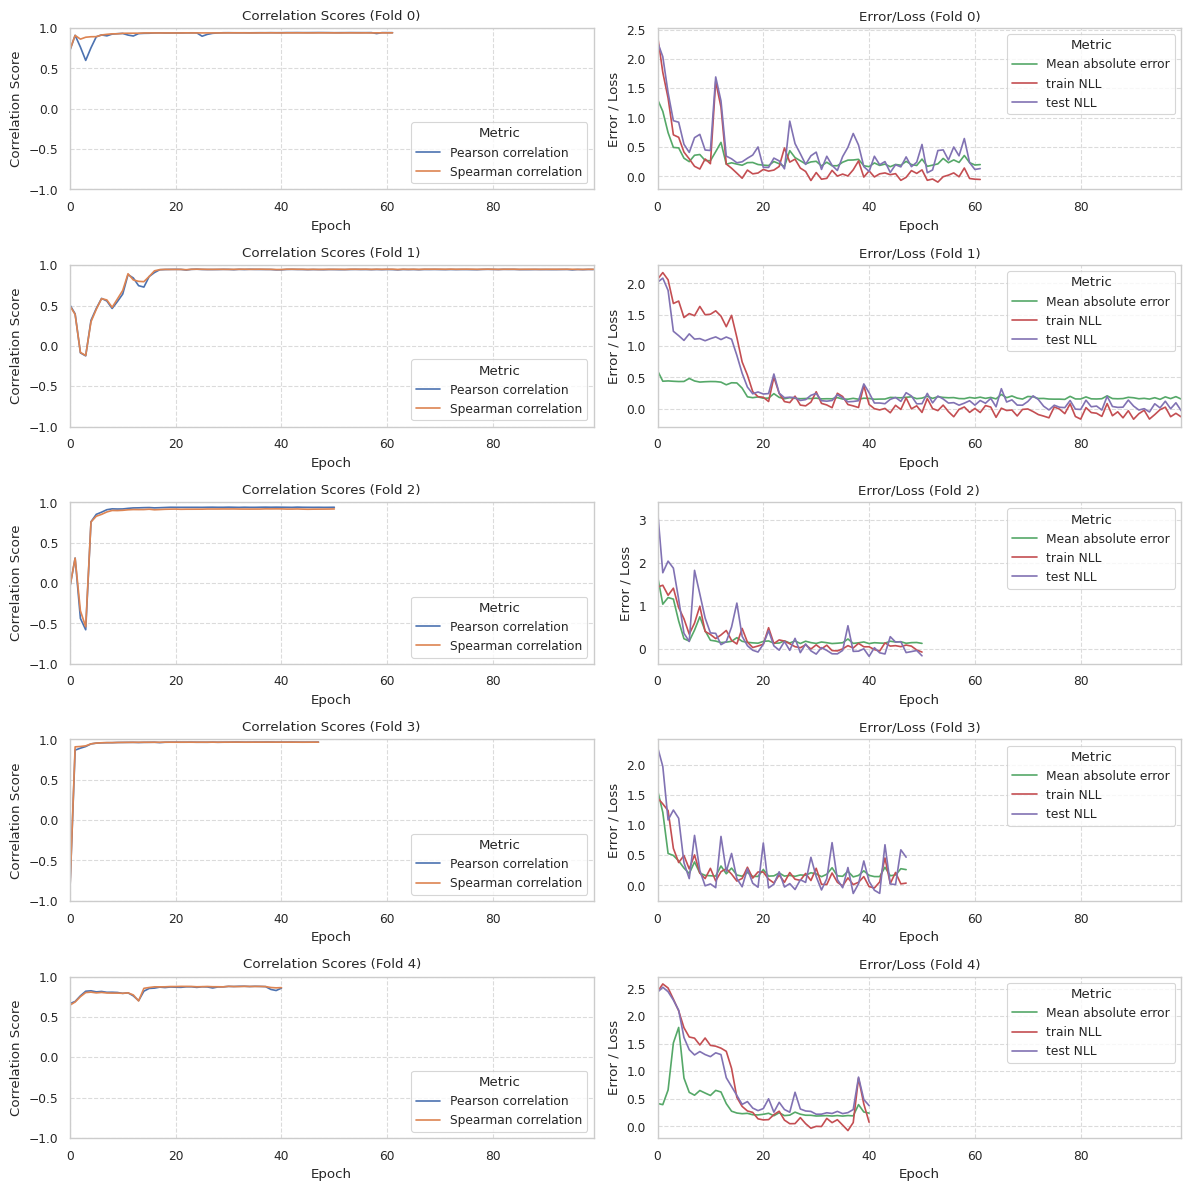

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper", style="whitegrid")

folds = sorted(stats['Fold'].unique())
n_folds = len(folds)

fig, axes = plt.subplots(nrows=n_folds, ncols=2, figsize=(12, 12), sharex=False)

for i, fold in enumerate(folds):
    fold_stats = stats[stats['Fold'] == fold]

    palette = sns.color_palette()

    # Plot correlations
    ax = axes[i, 0]

    # Convert to long format
    fold_stats_long = fold_stats.melt(
        id_vars='Epoch',
        value_vars=['Pearson correlation', 'Spearman correlation'],
        var_name='Metric',
        value_name='Correlation'
    )

    sns.lineplot(
        data=fold_stats_long,
        x='Epoch',
        y='Correlation',
        hue='Metric',
        palette={'Pearson correlation': palette[0], 'Spearman correlation': palette[1]},
        ax=ax
    )

    ax.set_title(f'Correlation Scores (Fold {fold})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Correlation Score')
    ax.set_ylim(-1, 1)
    ax.set_xlim(0, stats['Epoch'].max())
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(title='Metric', loc='lower right')

    # Plot errors
    ax = axes[i, 1]

    # Convert to long format
    fold_stats_long = fold_stats.melt(
        id_vars='Epoch',
        value_vars=['Mean absolute error', 'train NLL', 'test NLL'],
        var_name='Error / Loss',
        value_name='Value'
    )

    sns.lineplot(
        data=fold_stats_long,
        x='Epoch',
        y='Value',
        hue='Error / Loss',
        palette={'Mean absolute error': palette[2], 'train NLL': palette[3], 'test NLL': palette[4]},
        ax=ax
    )

    ax.set_title(f'Error/Loss (Fold {fold})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Error / Loss')
    # ax.set_ylim(0.98, 0.99)
    ax.set_xlim(0, stats['Epoch'].max())
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(title='Metric', loc='upper right')

plt.tight_layout()
plt.show()


In [19]:
notify.send(f'Training complete, results at {OUTPUT_DIR}')